# Fit the plate-position correction

Wells in a given row and column of a plate are shifted in a consistent, feature-specific direction (a "tilt") that is unrelated to what is in the well.
For example, compounds in row B look more healthy-like than the same kind of compound in row G.

This notebook **estimates** that tilt from the normalized single-cell profiles of all plates and writes the result to this folder.
It does not change any existing profiles.
Applying the correction is a separate step: `../3.apply_position_correction.ipynb` reads the saved fit (`position_correction_fit.npz`).
Rerun this notebook whenever the normalized profiles change.

**Method (details in `../utils/position_correction_utils.py`):**

1. Summarize each well as the median profile of its cells.
2. Average each compound's replicate plates, then center each platemap.
3. Fit a shared, additive row plus column effect per feature across all platemaps ("tilt map").
   Compounds were placed at random, so their own effects average out and the position effect remains.
4. Scale the tilt map per platemap with one amplitude, shrunk toward the average of the other platemaps.
5. A cell is corrected by subtracting `amplitude x tilt(row, column)` from its features.

Controls (DMSO and TGFRi) are never used to estimate the tilt.

## Import libraries

In [1]:
import os
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append("../../utils")
import position_correction_utils as pcu

## Set paths and variables

In [2]:
# directory containing batch_*/platemap_*/single_cell_profiles/ (only read when the cache is missing)
data_dir = pathlib.Path(os.environ.get("DATA_DIR", "../data"))
n_jobs = int(os.environ.get("N_JOBS", "4"))

output_dir = pathlib.Path(".")
figure_dir = output_dir / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# well-level summary is cached because reading every plate is slow
well_medians_cache = output_dir / "well_medians.parquet"

## Summarize every well

Each well becomes the median profile of its normalized cells.
Features with a missing value in any well cannot be modeled and are dropped.

In [3]:
if well_medians_cache.exists():
    well_medians = pd.read_parquet(well_medians_cache)
    meta_cols = ["plate", "platemap", "well", "treatment", "cell_type", "n"]
    features = [c for c in well_medians.columns if c not in meta_cols]
else:
    plate_table = pcu.discover_normalized_profiles(data_dir.resolve(strict=True))
    well_medians, features = pcu.build_well_medians(plate_table, n_jobs=n_jobs)
    well_medians.to_parquet(well_medians_cache, index=False)

print("Plates:", well_medians["plate"].nunique())
print("Platemaps:", sorted(well_medians["platemap"].unique()))
print("Wells:", len(well_medians))
print("Features:", len(features))

Plates: 44
Platemaps: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Wells: 2088
Features: 2446


## Fit the tilt map and platemap amplitudes

The fit uses every platemap.
Amplitudes are relative to the average tilt across platemaps (a typical platemap is close to 1).

In [4]:
fit = pcu.fit_position_correction(well_medians, features)

amplitudes = pd.DataFrame(
    [
        {
            "platemap": platemap,
            "raw_amplitude": fit["raw_amplitudes"][platemap][0],
            "standard_error": fit["raw_amplitudes"][platemap][1],
            "shrunk_amplitude": fit["amplitudes"][platemap],
        }
        for platemap in sorted(fit["amplitudes"])
    ]
)
amplitudes.to_csv(output_dir / "platemap_amplitudes.csv", index=False)
pcu.save_fit(fit, output_dir / "position_correction_fit.npz")
amplitudes.round(3)

,platemap,raw_amplitude,standard_error,shrunk_amplitude
0,1,0.659,0.245,0.898
1,2,1.191,0.129,1.136
2,3,0.916,0.146,0.952
3,4,1.051,0.141,1.040
4,5,0.910,0.101,0.933
5,6,1.030,0.118,1.027
6,7,1.283,0.118,1.200
7,8,1.301,0.142,1.188
8,9,0.667,0.209,0.877
9,10,1.264,0.153,1.162


## How large is the tilt, and how strongly does it apply to each platemap?

Left: the size of the tilt at each well position (root mean square over features, in normalized units).
Right: each platemap's amplitude before and after shrinkage.

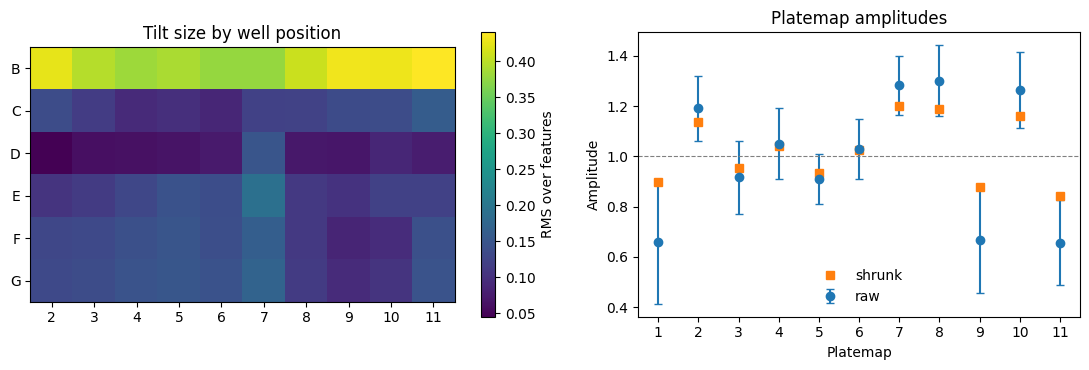

In [5]:
grid_rows, grid_cols = np.meshgrid(range(6), range(10), indexing="ij")
tilt_grid = pcu.tilt(
    fit["coef"], fit["center"], grid_rows.ravel(), grid_cols.ravel()
).reshape(6, 10, -1)
tilt_size = np.sqrt((tilt_grid**2).mean(axis=2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.2, 1]})
image = axes[0].imshow(tilt_size, cmap="viridis")
axes[0].set_xticks(range(10), labels=range(2, 12))
axes[0].set_yticks(range(6), labels=list(pcu.ROWS))
axes[0].set_title("Tilt size by well position")
fig.colorbar(image, ax=axes[0], label="RMS over features")

x = np.arange(len(amplitudes))
axes[1].errorbar(
    x,
    amplitudes["raw_amplitude"],
    yerr=amplitudes["standard_error"],
    fmt="o",
    label="raw",
    capsize=3,
)
axes[1].plot(x, amplitudes["shrunk_amplitude"], "s", label="shrunk")
axes[1].axhline(1, color="grey", lw=0.8, ls="--")
axes[1].set_xticks(x, labels=amplitudes["platemap"])
axes[1].set_xlabel("Platemap")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Platemap amplitudes")
axes[1].legend(frameon=False)
fig.tight_layout()
fig.savefig(figure_dir / "tilt_size_and_amplitudes.png", dpi=120)
plt.show()

## Effect on controls

The tilt is estimated from compound wells only, but it is subtracted from every well, including controls.
Healthy DMSO sits in row B and failing DMSO in row E, so the correction changes the healthy minus failing contrast.

In [6]:
wells = well_medians[well_medians["n"] >= 50].reset_index(drop=True)
wells["row"], wells["col"] = pcu.well_index(wells["well"])

offsets_all = np.vstack(
    [
        fit["amplitudes"][platemap]
        * pcu.tilt(
            fit["coef"],
            fit["center"],
            wells["row"].to_numpy()[idx],
            wells["col"].to_numpy()[idx],
        )
        for platemap, idx in wells.groupby("platemap").indices.items()
    ]
)
order = np.concatenate(list(wells.groupby("platemap").indices.values()))
wells_ordered = wells.iloc[order].reset_index(drop=True)
profiles_ordered = wells_ordered[features].to_numpy(float)

kind = np.where(
    (wells_ordered["treatment"] == "DMSO") & (wells_ordered["cell_type"] == "healthy"),
    "healthy DMSO",
    np.where(
        (wells_ordered["treatment"] == "DMSO") & (wells_ordered["cell_type"] == "failing"),
        "failing DMSO",
        np.where(wells_ordered["treatment"] == "TGFRi", "TGFRi", "compound"),
    ),
)
offset_size = pd.Series(np.sqrt((offsets_all**2).mean(axis=1)), name="mean offset (RMS)")
print(offset_size.groupby(kind).agg(["mean", "size"]).round(3))

contrasts = []
for plate, idx in wells_ordered.groupby("plate").indices.items():
    labels = kind[idx]
    healthy, failing = idx[labels == "healthy DMSO"], idx[labels == "failing DMSO"]
    if len(healthy) == 0 or len(failing) == 0:
        continue
    raw = profiles_ordered[healthy].mean(axis=0) - profiles_ordered[failing].mean(axis=0)
    corrected = (profiles_ordered[healthy] - offsets_all[healthy]).mean(axis=0) - (
        profiles_ordered[failing] - offsets_all[failing]
    ).mean(axis=0)
    contrasts.append(
        {
            "plate": plate,
            "raw_norm": np.linalg.norm(raw),
            "corrected_norm": np.linalg.norm(corrected),
            "cosine": raw @ corrected / np.linalg.norm(raw) / np.linalg.norm(corrected),
        }
    )
contrasts = pd.DataFrame(contrasts)
contrasts["ratio"] = contrasts["corrected_norm"] / contrasts["raw_norm"]
print(
    f"\nHealthy minus failing DMSO contrast over {len(contrasts)} plates: "
    f"median norm ratio (corrected / raw) {contrasts['ratio'].median():.2f}, "
    f"median cosine {contrasts['cosine'].median():.2f}"
)

               mean  size
compound      0.152  1505
failing DMSO  0.124   169
healthy DMSO  0.427   168

Healthy minus failing DMSO contrast over 43 plates: median norm ratio (corrected / raw) 0.84, median cosine 0.26


## Assumptions and limits

- **Additive and shared shape.** Position adds a fixed vector to every cell in a well.
  The shape of the tilt is the same on every platemap, and only its size (the amplitude) differs.
- **Random placement.** Compounds were placed independently of their effects, so they average out of the tilt estimate.
  This was not checked against pathway or chemotype.
- **Healthy cells only in row B.** The correction assumes position moves healthy and failing cells equally.
  Nothing in this screen can test that, and it matters because controls are corrected too.
- **Amplitudes are relative.** Only the tilt scaled by the amplitude is identified, so a typical amplitude is about 1.
- **Features with missing values** are dropped and cannot be corrected.
- The fit here uses every platemap, so it cannot show that the correction works.
  See `validate_position_correction.ipynb` for held-out validation.